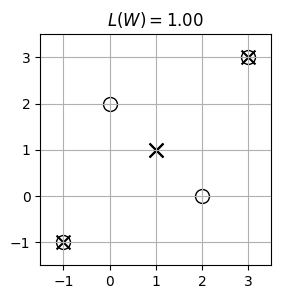

In [4]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ])
N = len(X)
K = 1

_, _, Vt = np.linalg.svd(X - X.mean(0))
W = Vt[:K, :].T
Z = X @ W
hX = Z @ W.T
L = np.square(X - hX).sum(axis=1).mean()

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.grid(True)
ax.set_title(f'$L(W)={L:.2f}$')
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=100)
plt.scatter(*hX.T, facecolor='black', s=100, marker='x')

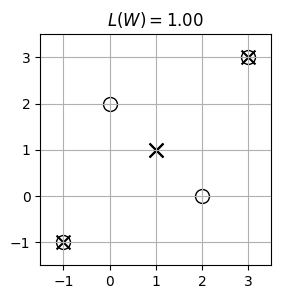

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array([[-1, -1], [0, 2], [2, 0], [3, 3]])
N = len(X)
K = 1
pca = PCA(n_components=K).fit(X - X.mean(0))
Z = pca.transform(X)
hX = pca.inverse_transform(Z)
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.grid(True)
ax.set_title(f"$L(W)={L:.2f}$")
plt.scatter(*X.T, facecolor="white", edgecolor="k", s=100)
plt.scatter(*hX.T, facecolor="black", s=100, marker="x")

In [6]:
import numpy as np
import datasets

ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
ds

/home/sergio/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 992100.67 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [7]:
train0 = ds['train'][0]
train0['image'].shape, train0['image'].dtype, train0['label']

((28, 28), dtype('uint8'), np.int64(5))

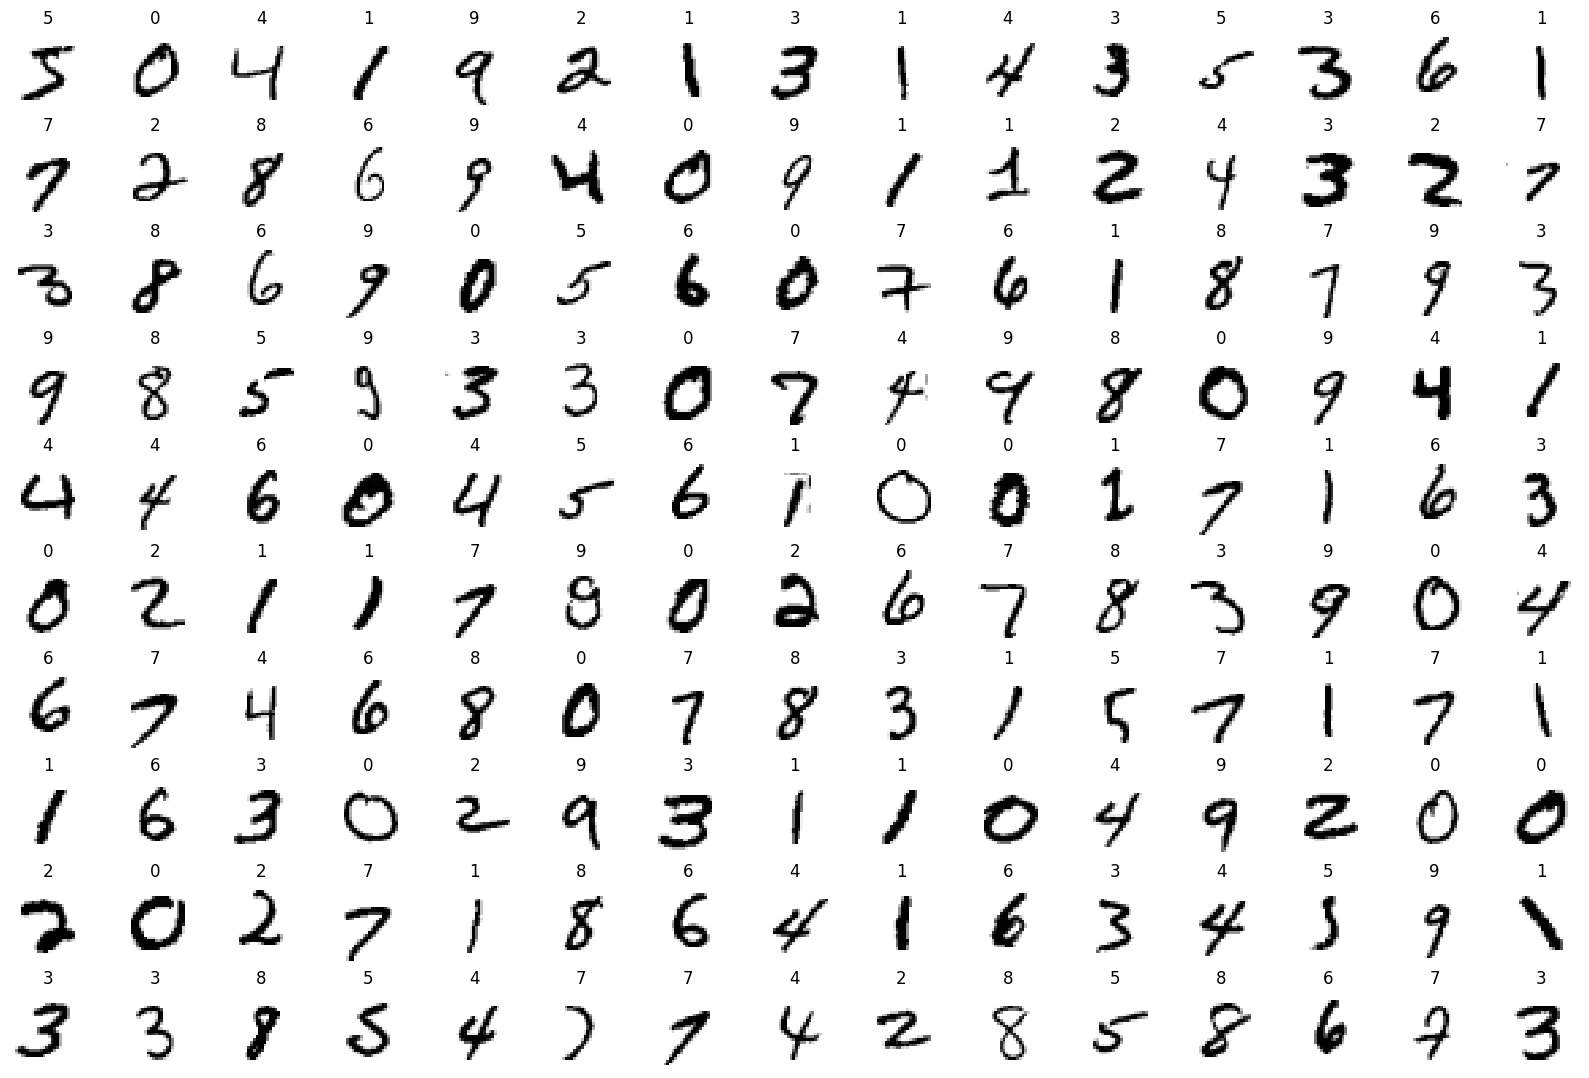

In [8]:
import matplotlib.pyplot as plt

nrows = 10
ncols = 15
N = nrows * ncols
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(y)

In [9]:
import numpy as np
import datasets

ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

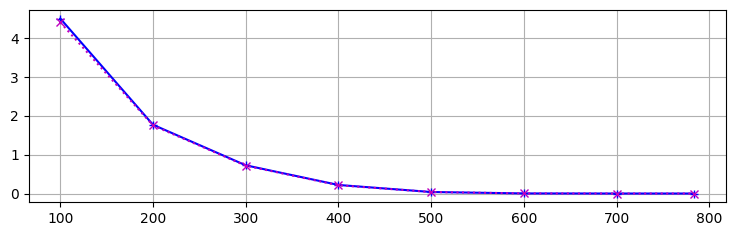

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

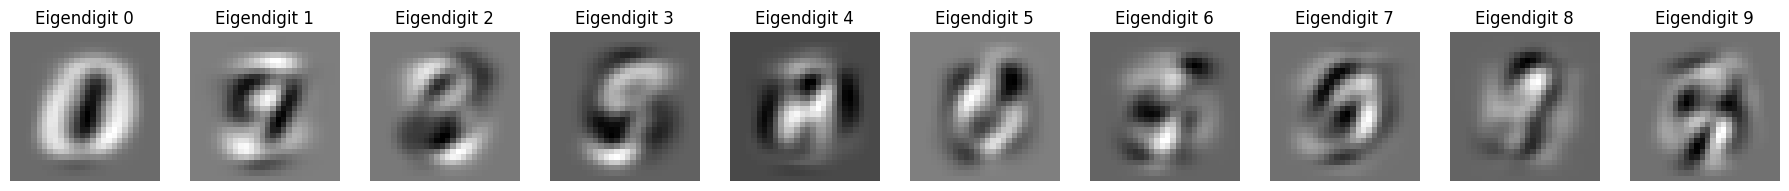

In [11]:
K = 400
pca = PCA(n_components=K).fit(X_train)
nrows, ncols = 1, 10
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none"
    )

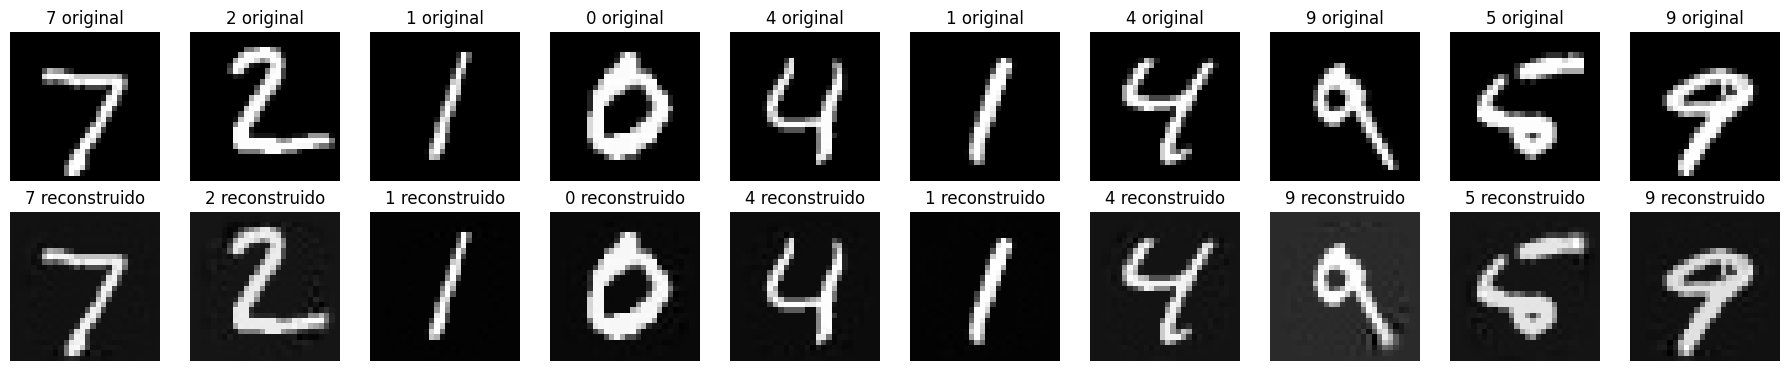

In [12]:
ncols = 10
Z_test = pca.transform(X_test[:ncols])
hX_test = pca.inverse_transform(Z_test)
fig, axs = plt.subplots(
    nrows=2, ncols=10, figsize=(18, 18 * 2 / ncols), constrained_layout=True
)
for i in range(ncols):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} original")
    ax.imshow(X_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")
    ax = axs.flat[ncols + i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} reconstruido")
    ax.imshow(hX_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")

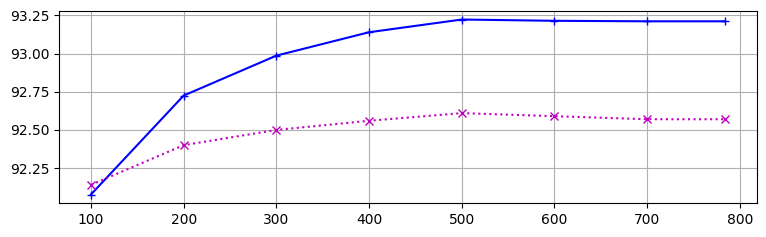

In [13]:
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.1, max_iter=200).fit(Z_train[:, :K], y_train)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m")

<br>

# FASHION MNIST

In [ ]:
import numpy as np
import datasets

ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy")
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [22]:
train0 = ds['train'][0]
train0['image'].shape, train0['image'].dtype, train0['label']

((28, 28), dtype('uint8'), np.int64(9))

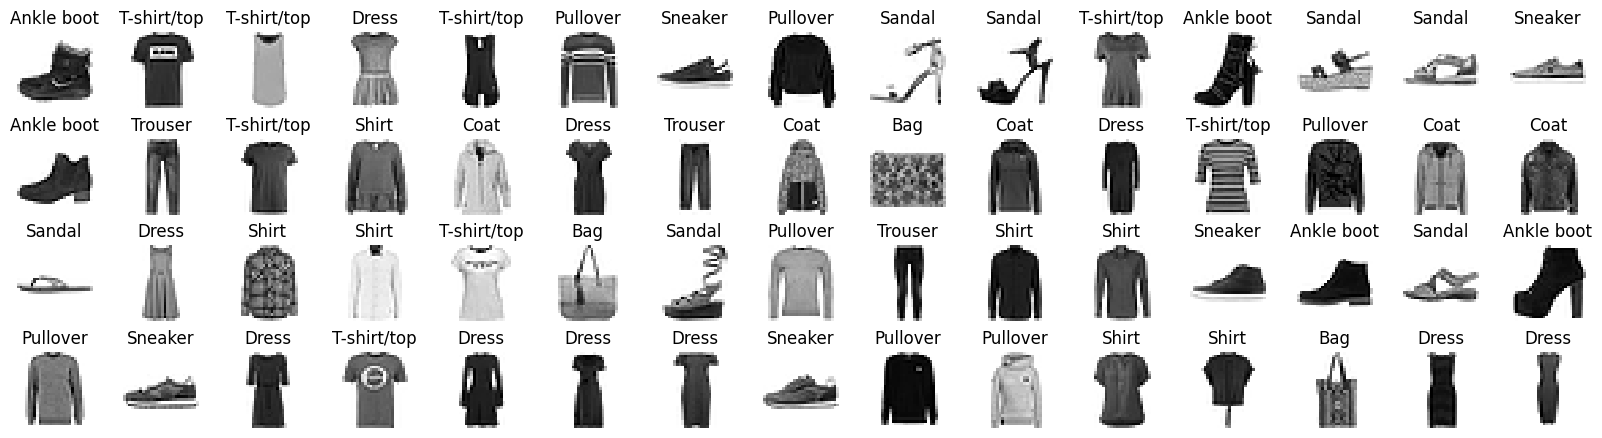

In [23]:
import matplotlib.pyplot as plt

nrows = 4
ncols = 15
N = nrows * ncols
labels = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(labels[y])

In [24]:
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

100 Error: 6.005016326904297
200 Error: 3.202116012573242
300 Error: 1.8371460437774658
400 Error: 1.0318964719772339
500 Error: 0.5244814157485962
600 Error: 0.21142753958702087
700 Error: 0.039095405489206314
784 Error: 2.0631964886552723e-11


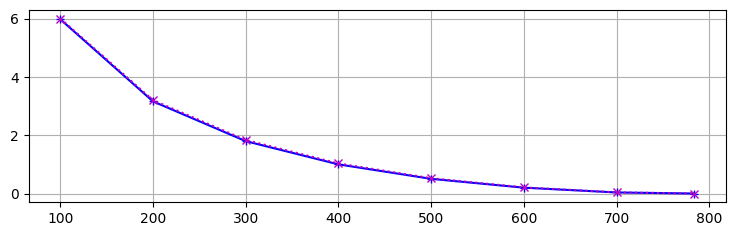

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
    print(K, f"Error: {np.square(X_test - hX_test).sum(axis=1).mean()}")
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

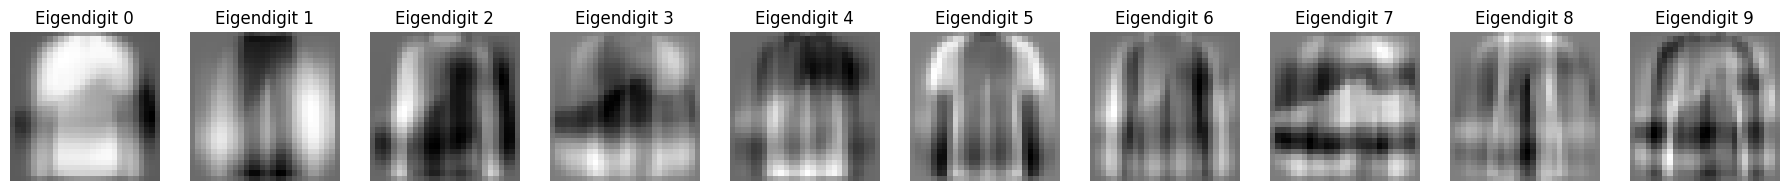

In [32]:
K = 600
pca = PCA(n_components=K).fit(X_train)
nrows, ncols = 1, 10
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none"
    )

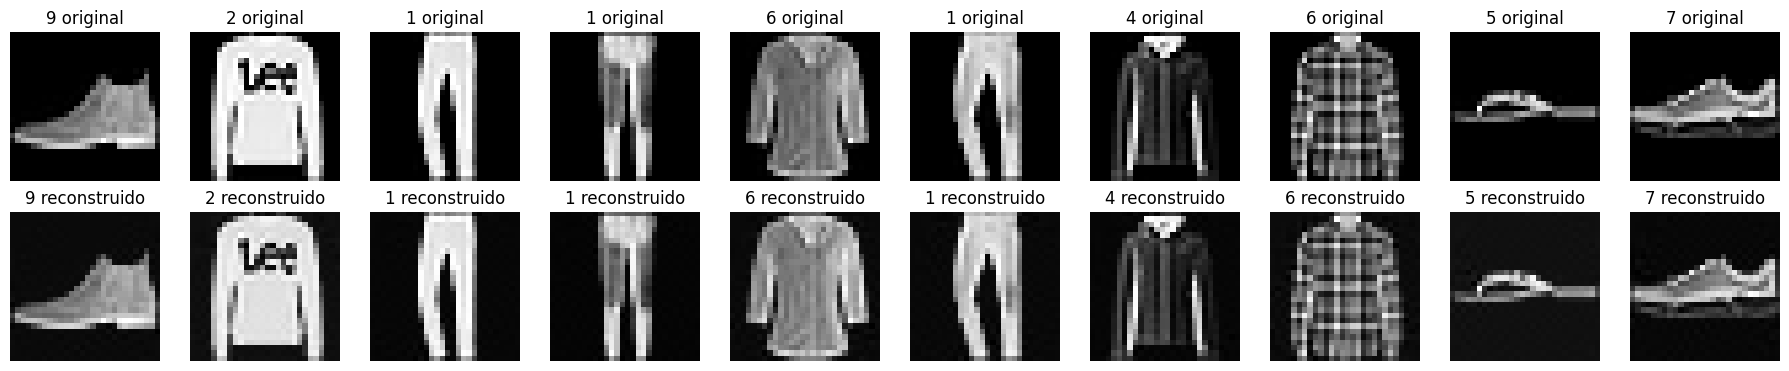

In [33]:
ncols = 10
Z_test = pca.transform(X_test[:ncols])
hX_test = pca.inverse_transform(Z_test)
fig, axs = plt.subplots(
    nrows=2, ncols=10, figsize=(18, 18 * 2 / ncols), constrained_layout=True
)
for i in range(ncols):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} original")
    ax.imshow(X_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")
    ax = axs.flat[ncols + i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} reconstruido")
    ax.imshow(hX_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")

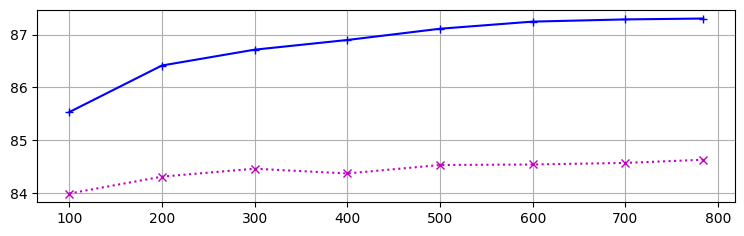

In [35]:
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.1, max_iter=1000).fit(Z_train[:, :K], y_train)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m")

<br>

# CIFAR10 DATASET

In [36]:
import numpy as np; import datasets
ds = datasets.load_dataset("uoft-cs/cifar10").with_format("numpy"); ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [37]:
train0 = ds['train'][0]
train0['img'].shape, train0['img'].dtype, train0['label']

((32, 32, 3), dtype('uint8'), np.int64(0))

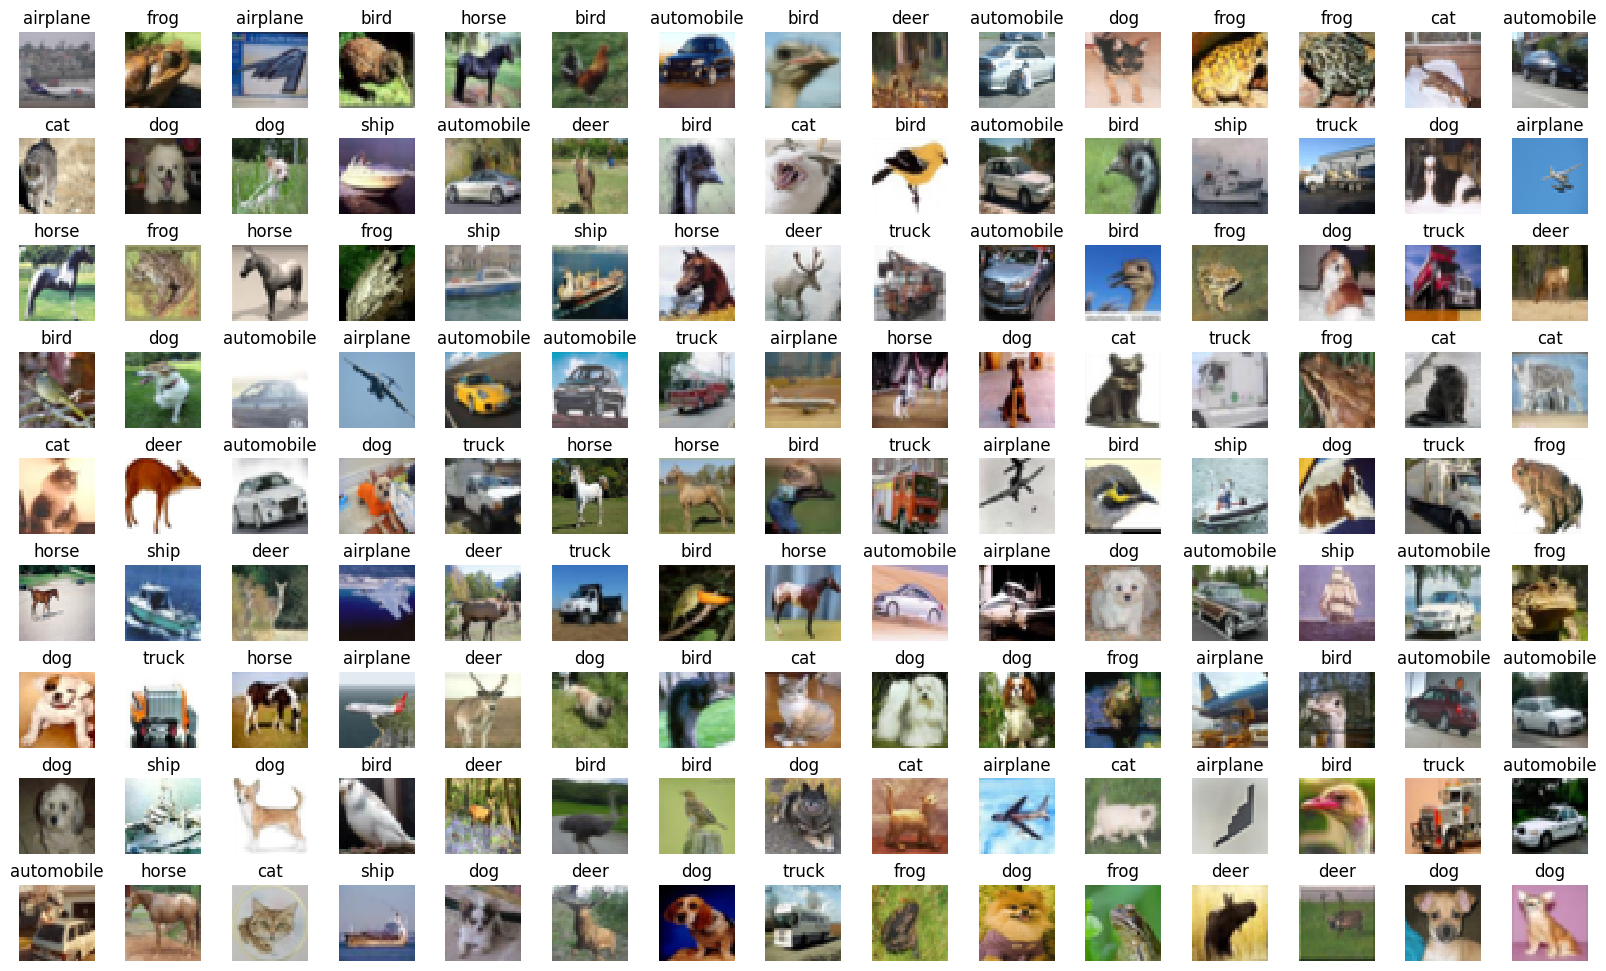

In [38]:
import matplotlib.pyplot as plt

nrows = 9
ncols = 15
N = nrows * ncols
labels = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["img"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(labels[y])

In [39]:
X_train = ds["train"][:]["img"].astype(np.float32).reshape(-1, 32 * 32 * 3) / 255.0
y_train = ds["train"][:]["label"].astype(np.uint8)
X_test = ds["test"][:]["img"].astype(np.float32).reshape(-1, 32 * 32 * 3) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")